In [2]:
import pandas as pd
indicator_log_path = 'CAN_Reverse_Engineering_Project/logs/6_2012 Subaru Impreza/indicator/6_indicator_CAN.log'
df_can = pd.read_csv(indicator_log_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
df_can['id'] = df_can['raw_frame'].str[0:3]
df_can['timestamp'] = df_can['timestamp'].str[1:-1].astype(float)
df_can['payload'] = df_can['raw_frame'].str[4:18]
df_can

,timestamp,bus,raw_frame,id,payload
0,1.721117e+09,can0,140#0006004000000B01,140,0006004000000B
1,1.721117e+09,can0,141#1B262A2800803800,141,1B262A28008038
2,1.721117e+09,can0,280#0003100000000000,280,00031000000000
3,1.721117e+09,can0,148#0E1200804100FF01,148,0E1200804100FF
4,1.721117e+09,can0,149#84013F009D000000,149,84013F009D0000
...,...,...,...,...,...
166763,1.721117e+09,can0,002#FFEA700F68000000,002,FFEA700F680000
166764,1.721117e+09,can0,140#000C004000000C01,140,000C004000000C
166765,1.721117e+09,can0,141#1B262F2800803800,141,1B262F28008038
166766,1.721117e+09,can0,360#0000626BDF000000,360,0000626BDF0000


In [3]:
indicator_annot_path = 'CAN_Reverse_Engineering_Project/logs/6_2012 Subaru Impreza/indicator/6_indicator_annot.log'
df_annot = pd.read_csv(indicator_annot_path, sep=',', header=None, names=['timestamp', 'action'])
df_annot

,timestamp,action
0,1721117268,Left Indicator Off
1,1721117279,Left Indicator On
2,1721117290,Left Indicator Off
3,1721117301,Left Indicator On
4,1721117312,Left Indicator Off
5,1721117323,Left Indicator On
6,1721117334,Left Indicator Off
7,1721117345,Right Indicator On
8,1721117356,Right Indicator Off
9,1721117367,Right Indicator On


In [4]:
# 2. Isolate the target ID
target_id = '282'
df_282 = df_can[df_can['id'] == target_id].copy()

# 3. Create a function to find the "illuminated" payload in the time window
def get_payload_at_time(df, target_time):
    # Find all CAN messages broadcast in the 1 second after the switch was flipped
    mask = (df['timestamp'] >= target_time) & (df['timestamp'] <= target_time + 1.0)
    window_df = df[mask]
    
    if window_df.empty:
        return None
        
    # To avoid the "blinker problem" where we accidentally grab an 'off' frame,
    # we scan the 1-second window for any frame where Byte 5 isn't 00.
    for payload in window_df['payload']:
        if len(payload) == 16 and payload[10:12] != '00':
            return payload
            
    # If we don't find an active one (e.g., when turning it OFF), just return the first frame
    return window_df.iloc[0]['payload']

# 4. Cross-reference the annotations with the CAN traffic
results = []
for index, row in df_annot.iterrows():
    action_time = row['timestamp']
    action_name = row['action']
    
    payload = get_payload_at_time(df_282, action_time)
    
    if payload and len(payload) == 16: # Ensure we have a full 8-byte payload
        # Extract Byte 5 (characters 10 and 11 of the 16-character hex string)
        byte_5_hex = payload[10:12]
        
        # Convert hex to an 8-bit binary string for visualization
        byte_5_bin = bin(int(byte_5_hex, 16))[2:].zfill(8)
        
        results.append({
            'Action': action_name,
            'Time': action_time,
            'Full Payload': payload,
            'Byte 5 (Hex)': byte_5_hex,
            'Byte 5 (Bin)': byte_5_bin
        })

# 5. Display the verification table
df_results = pd.DataFrame(results)
print(f"--- Verification for CAN ID {target_id} ---")
df_results

--- Verification for CAN ID 282 ---


""


In [5]:
# import pandas as pd
# import numpy as np

# print("Hunting for the REAL Turn Signal ID across all CAN frames...")

# # 1. Label the data using a 1.5s window to catch the "blinking" ON state
# df_can['label'] = 'Background'
# event_window = 1.5 

# for index, row in df_annot.iterrows():
#     event_label = row['action'].replace(' ', '_')
#     start_time = row['timestamp']
#     end_time = start_time + event_window
#     mask = (df_can['timestamp'] >= start_time) & (df_can['timestamp'] < end_time)
#     df_can.loc[mask, 'label'] = event_label

# all_ids = df_can['id'].unique()
# print(f"Found {len(all_ids)} unique IDs. Correlating bits...")

# # Fast helper function to convert hex strings to padded binary arrays
# def hex_to_bin_array(hex_str):
#     if pd.isna(hex_str):
#         return np.zeros(64, dtype=np.int8)
#     bin_str = bin(int(hex_str, 16))[2:].zfill(len(hex_str)*4)
#     return np.array([int(b) for b in bin_str], dtype=np.int8)

# results = []

# # 2. Loop through every CAN ID to find the needle in the haystack
# for can_id in all_ids:
#     df_target = df_can[df_can['id'] == can_id].copy()
    
#     # Check if this ID actually exists during the 'ON' events
#     labels_present = df_target['label'].unique()
#     if 'Left_Indicator_On' not in labels_present and 'Right_Indicator_On' not in labels_present:
#         continue
        
#     # Skip IDs where the payload never changes
#     unique_payloads = df_target['payload'].unique()
#     if len(unique_payloads) == 1:
#         continue 
        
#     # Convert payloads to binary DataFrame
#     bit_arrays = np.vstack(df_target['payload'].apply(hex_to_bin_array).values)
#     df_bits = pd.DataFrame(bit_arrays, index=df_target.index)
#     df_bits['label'] = df_target['label']
    
#     # Calculate the average state of each bit for each labeled event
#     summary = df_bits.groupby('label').mean()
    
#     for bit_index in summary.columns:
#         # --- Check LEFT SIGNAL ---
#         if 'Left_Indicator_On' in summary.index and 'Left_Indicator_Off' in summary.index:
#             val_on = summary.loc['Left_Indicator_On', bit_index]
#             val_off = summary.loc['Left_Indicator_Off', bit_index]
            
#             # If the bit is quiet during 'OFF' but toggles frequently during 'ON'
#             if val_off < 0.05 and val_on > 0.15:
#                 results.append(f"🎯 LEFT SIGNAL FOUND: ID {can_id} | Bit Position: {bit_index} | (Off state: {val_off:.2f}, On state: {val_on:.2f})")
                
#         # --- Check RIGHT SIGNAL ---
#         if 'Right_Indicator_On' in summary.index and 'Right_Indicator_Off' in summary.index:
#             val_on = summary.loc['Right_Indicator_On', bit_index]
#             val_off = summary.loc['Right_Indicator_Off', bit_index]
            
#             if val_off < 0.05 and val_on > 0.15:
#                 results.append(f"🎯 RIGHT SIGNAL FOUND: ID {can_id} | Bit Position: {bit_index} | (Off state: {val_off:.2f}, On state: {val_on:.2f})")

# # 3. Print the big reveal
# print("\n" + "="*50)
# if not results:
#     print("No obvious turn signal bits found. They might be multiplexed or absent from this high-speed bus.")
# else:
#     for r in results:
#         print(r)
# print("="*50)

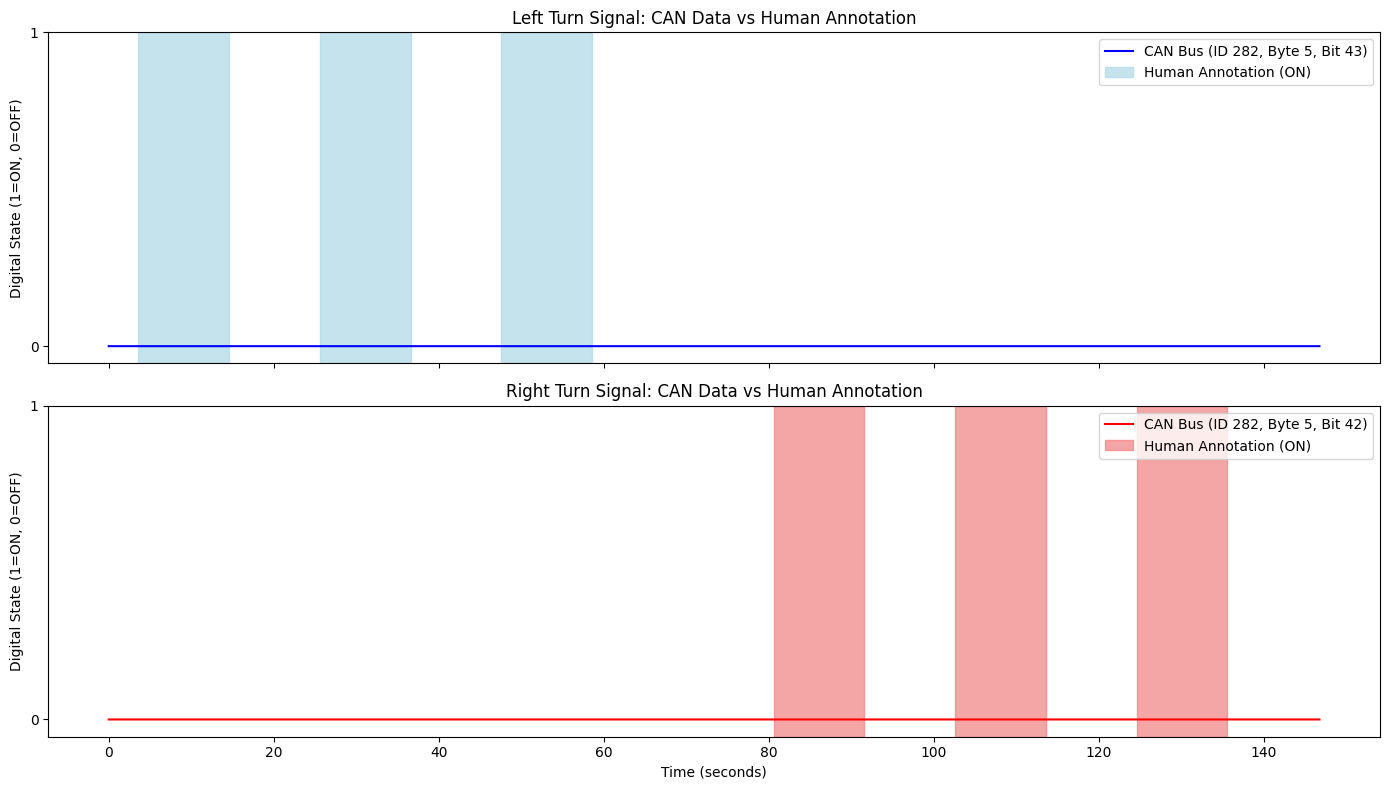

In [6]:
import matplotlib.pyplot as plt

# 1. Filter the CAN data for ID 282
df_282 = df_can[df_can['id'] == '282'].copy()

# 2. Extract the Left and Right bit states from Byte 5
# Hex '10' is 00010000 (Left), Hex '20' is 00100000 (Right)
def get_signal_states(payload):
    if len(payload) == 16:
        try:
            byte_5_val = int(payload[10:12], 16)
            left_state = 1 if (byte_5_val & 0x10) else 0
            right_state = 1 if (byte_5_val & 0x20) else 0
            return left_state, right_state
        except ValueError:
            pass
    return 0, 0

df_282['left_signal'], df_282['right_signal'] = zip(*df_282['payload'].apply(get_signal_states))

# Normalize timestamps to start at 0 for easier reading
start_time = min(df_282['timestamp'].min(), df_annot['timestamp'].min())
df_282['rel_time'] = df_282['timestamp'] - start_time
df_annot['rel_time'] = df_annot['timestamp'] - start_time

# 3. Prepare the plotting window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- PLOT 1: LEFT SIGNAL ---
# Plot the actual CAN bus data
ax1.step(df_282['rel_time'], df_282['left_signal'], where='post', color='blue', label='CAN Bus (ID 282, Byte 5, Bit 43)')

# Overlay the human annotations as shaded regions
left_on_times = df_annot[df_annot['action'] == 'Left Indicator On']['rel_time'].tolist()
left_off_times = df_annot[df_annot['action'] == 'Left Indicator Off']['rel_time'].tolist()

for i in range(min(len(left_on_times), len(left_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax1.axvspan(left_on_times[i], left_off_times[i], color='lightblue', alpha=0.7, label=label)

ax1.set_title('Left Turn Signal: CAN Data vs Human Annotation')
ax1.set_ylabel('Digital State (1=ON, 0=OFF)')
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right')

# --- PLOT 2: RIGHT SIGNAL ---
# Plot the actual CAN bus data
ax2.step(df_282['rel_time'], df_282['right_signal'], where='post', color='red', label='CAN Bus (ID 282, Byte 5, Bit 42)')

# Overlay the human annotations as shaded regions
right_on_times = df_annot[df_annot['action'] == 'Right Indicator On']['rel_time'].tolist()
right_off_times = df_annot[df_annot['action'] == 'Right Indicator Off']['rel_time'].tolist()

for i in range(min(len(right_on_times), len(right_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax2.axvspan(right_on_times[i], right_off_times[i], color='lightcoral', alpha=0.7, label=label)

ax2.set_title('Right Turn Signal: CAN Data vs Human Annotation')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Digital State (1=ON, 0=OFF)')
ax2.set_yticks([0, 1])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

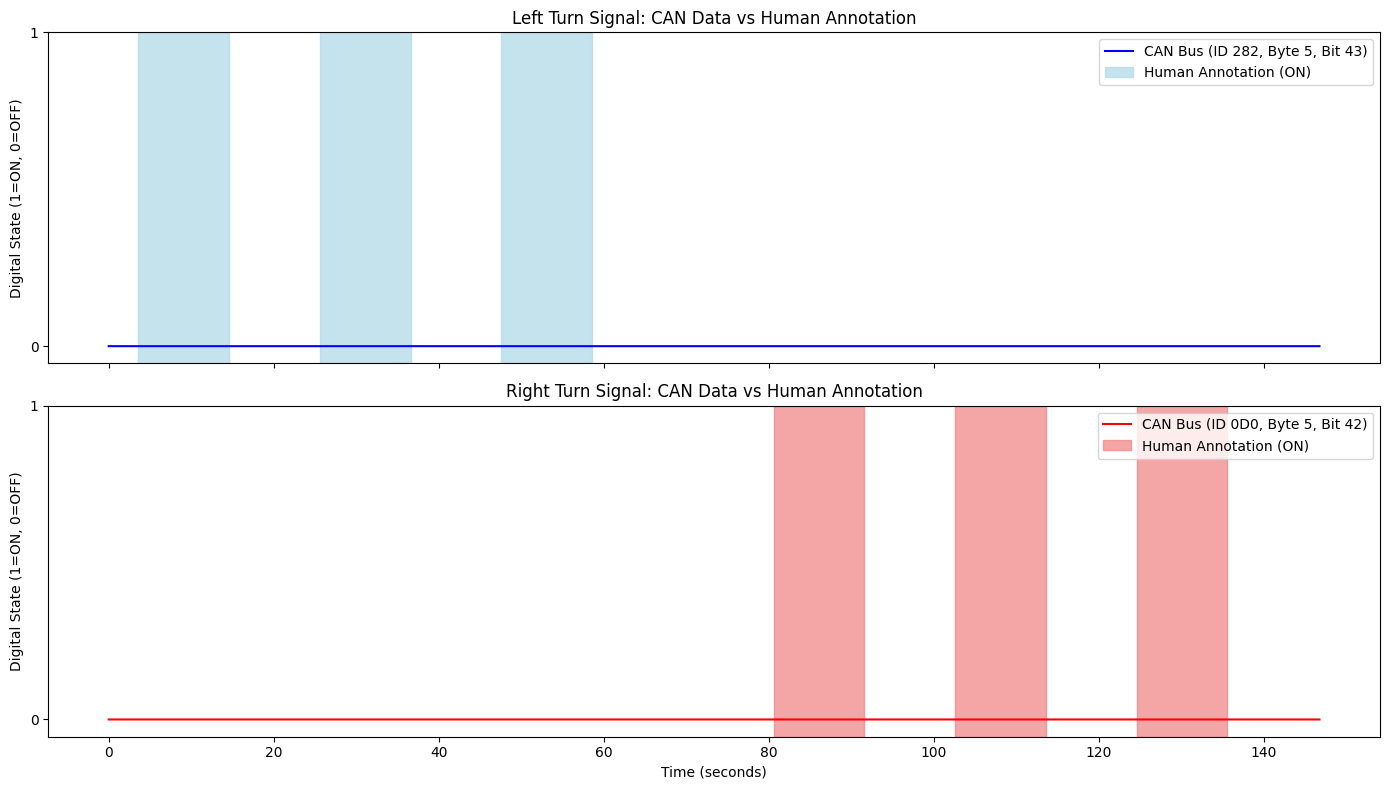

In [7]:
import matplotlib.pyplot as plt

# 1. Filter the CAN data for ID 282
df_0D0 = df_can[df_can['id'] == '0D0'].copy()

# 2. Extract the Left and Right bit states from Byte 5
# Hex '10' is 00010000 (Left), Hex '20' is 00100000 (Right)
def get_signal_states(payload):
    if len(payload) == 16:
        try:
            byte_5_val = int(payload[10:12], 16)
            left_state = 1 if (byte_5_val & 0x10) else 0
            right_state = 1 if (byte_5_val & 0x20) else 0
            return left_state, right_state
        except ValueError:
            pass
    return 0, 0

df_0D0['left_signal'], df_0D0['right_signal'] = zip(*df_0D0['payload'].apply(get_signal_states))

# Normalize timestamps to start at 0 for easier reading
start_time = min(df_0D0['timestamp'].min(), df_annot['timestamp'].min())
df_0D0['rel_time'] = df_0D0['timestamp'] - start_time
df_annot['rel_time'] = df_annot['timestamp'] - start_time

# 3. Prepare the plotting window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- PLOT 1: LEFT SIGNAL ---
# Plot the actual CAN bus data
ax1.step(df_0D0['rel_time'], df_0D0['left_signal'], where='post', color='blue', label='CAN Bus (ID 282, Byte 5, Bit 43)')

# Overlay the human annotations as shaded regions
left_on_times = df_annot[df_annot['action'] == 'Left Indicator On']['rel_time'].tolist()
left_off_times = df_annot[df_annot['action'] == 'Left Indicator Off']['rel_time'].tolist()

for i in range(min(len(left_on_times), len(left_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax1.axvspan(left_on_times[i], left_off_times[i], color='lightblue', alpha=0.7, label=label)

ax1.set_title('Left Turn Signal: CAN Data vs Human Annotation')
ax1.set_ylabel('Digital State (1=ON, 0=OFF)')
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right')

# --- PLOT 2: RIGHT SIGNAL ---
# Plot the actual CAN bus data
ax2.step(df_0D0['rel_time'], df_0D0['right_signal'], where='post', color='red', label='CAN Bus (ID 0D0, Byte 5, Bit 42)')

# Overlay the human annotations as shaded regions
right_on_times = df_annot[df_annot['action'] == 'Right Indicator On']['rel_time'].tolist()
right_off_times = df_annot[df_annot['action'] == 'Right Indicator Off']['rel_time'].tolist()

for i in range(min(len(right_on_times), len(right_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax2.axvspan(right_on_times[i], right_off_times[i], color='lightcoral', alpha=0.7, label=label)

ax2.set_title('Right Turn Signal: CAN Data vs Human Annotation')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Digital State (1=ON, 0=OFF)')
ax2.set_yticks([0, 1])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_can_bits(df_can, df_annot, target_id, bit_positions):
    """
    Extracts and plots specific bit positions for a given CAN ID,
    overlaying human annotations as shaded regions.
    """
    
    # 1. Filter the CAN data for the target ID
    df_filtered = df_can[df_can['id'] == target_id].copy()

    if df_filtered.empty:
        print(f"No data found for ID {target_id}")
        return

    # 2. Helper to extract bits from hex payload
    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or len(payload) == 0:
            return 0
        try:
            # Convert hex to binary, padding to the full byte length (2 hex chars = 8 bits)
            expected_bits = len(payload) * 4
            bin_str = bin(int(payload, 16))[2:].zfill(expected_bits)
            
            # CAN bits are often indexed from the left (MSB) or right (LSB)
            # This follows standard string indexing (0 is the very first bit of the payload)
            if bit_idx < len(bin_str):
                return int(bin_str[bit_idx])
        except ValueError:
            pass
        return 0

    for bit in bit_positions:
        col_name = f'bit_{bit}'
        df_filtered[col_name] = df_filtered['payload'].apply(lambda x: get_bit_state(x, bit))

    # 3. Synchronize Timestamps
    start_time = min(df_filtered['timestamp'].min(), df_annot['timestamp'].min())
    df_filtered['rel_time'] = df_filtered['timestamp'] - start_time
    
    # 4. Process Human Annotations into valid Start-End pairs
    # This prevents the "backwards" or shifted shading issue
    df_a = df_annot.sort_values('timestamp').copy()
    df_a['rel_time'] = df_a['timestamp'] - start_time

    intervals = []
    temp_on_time = None

    for _, row in df_a.iterrows():
        action = str(row['action']).strip().lower()
        if 'on' in action:
            temp_on_time = row['rel_time']
        elif 'off' in action and temp_on_time is not None:
            intervals.append((temp_on_time, row['rel_time']))
            temp_on_time = None # Reset to look for the next "On"

    # 5. Dynamic Plotting
    num_plots = len(bit_positions)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 4 * num_plots), sharex=True)
    
    if num_plots == 1:
        axes = [axes]
        
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, bit in enumerate(bit_positions):
        ax = axes[i]
        col_name = f'bit_{bit}'
        color = colors[i % len(colors)]
        
        # Plot the CAN bus data as a step function
        ax.step(df_filtered['rel_time'], df_filtered[col_name], where='post', 
                color=color, linewidth=2, label=f'CAN ID {target_id} | Bit {bit}')

        # Overlay the processed annotation intervals
        for j, (start, end) in enumerate(intervals):
            label = 'Human Annotation (Active)' if j == 0 else ""
            ax.axvspan(start, end, color='gray', alpha=0.3, label=label)

        ax.set_title(f'Digital State Analysis: Bit {bit}')
        ax.set_ylabel('State (1/0)')
        ax.set_yticks([0, 1])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Relative Time (seconds)')
    plt.tight_layout()
    plt.show()

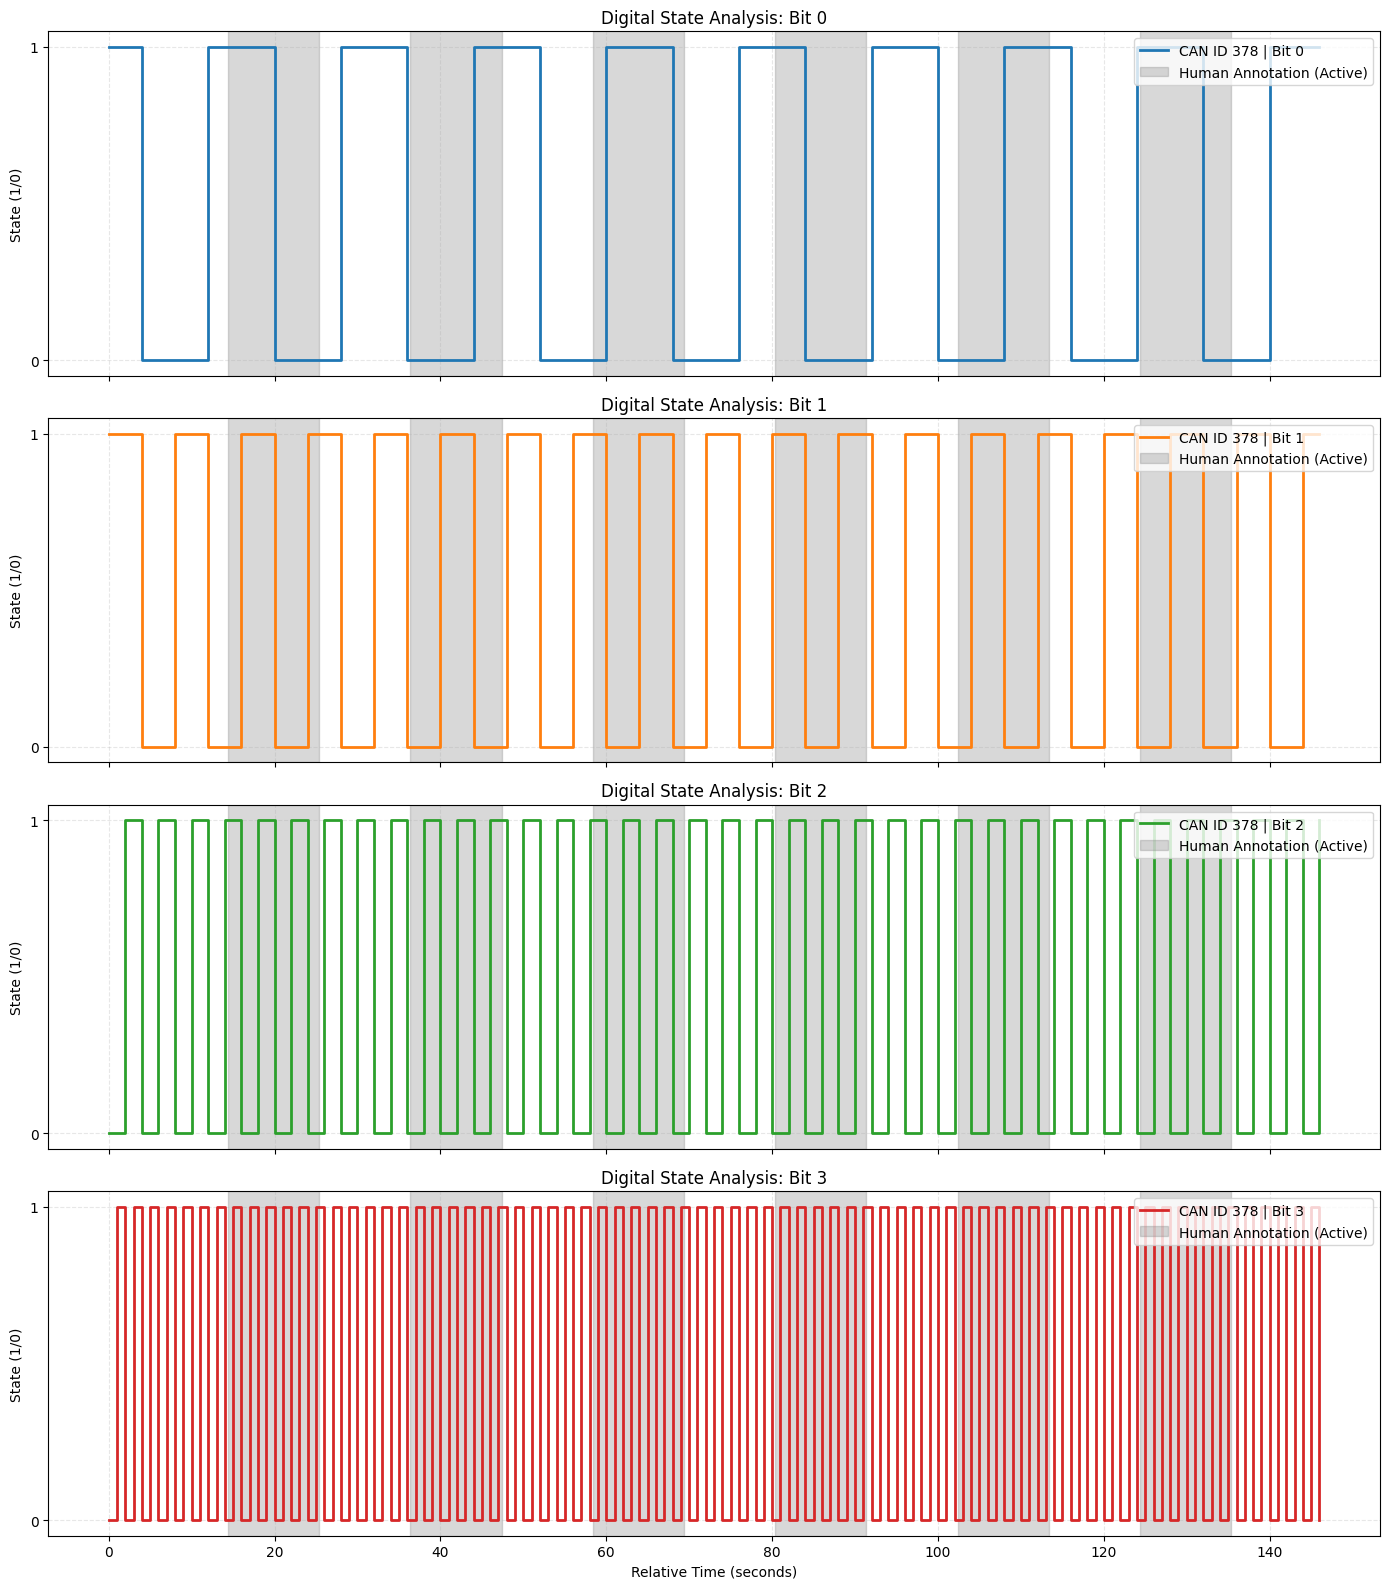

In [9]:
plot_can_bits(df_can, df_annot, target_id='378', bit_positions=[0,1,2,3])

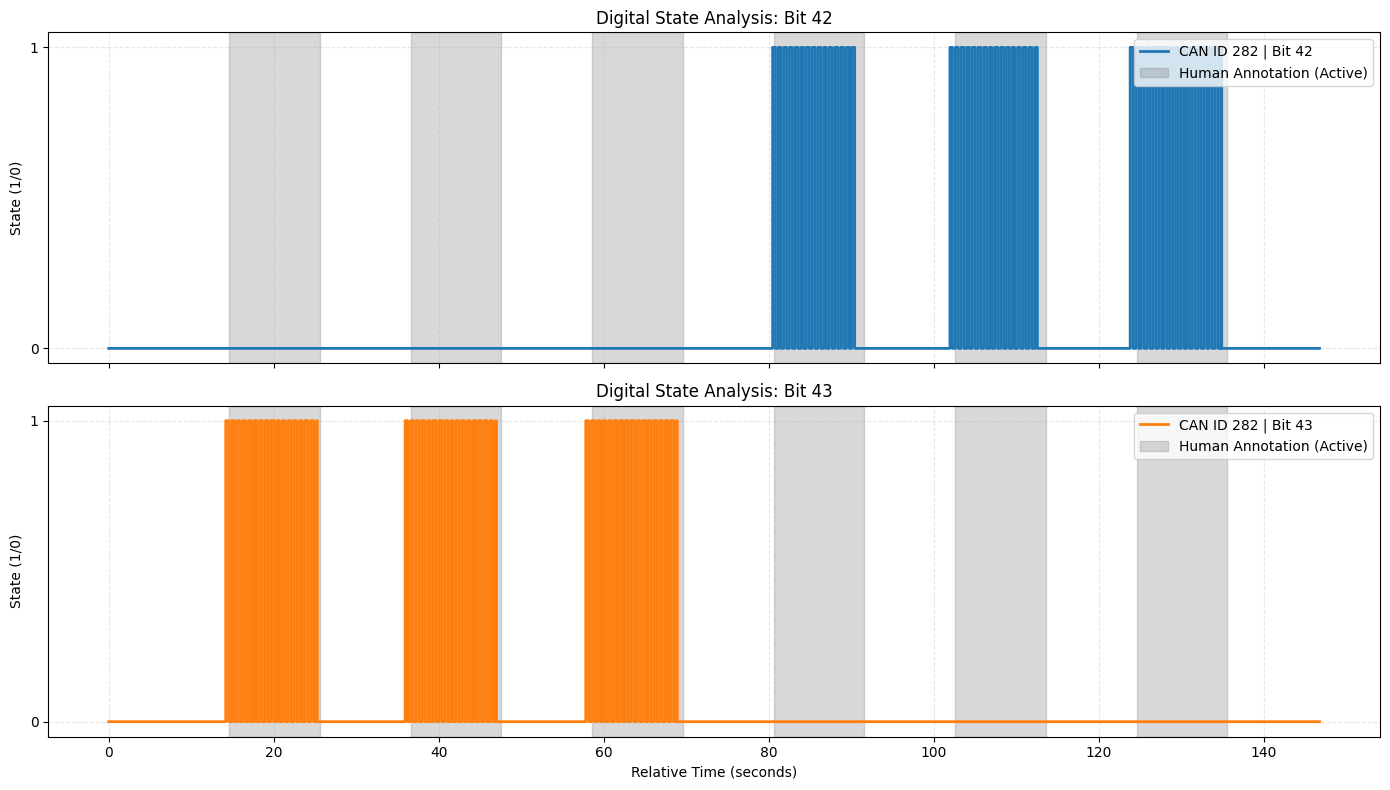

In [10]:
plot_can_bits(df_can, df_annot, target_id='282', bit_positions=[42, 43])

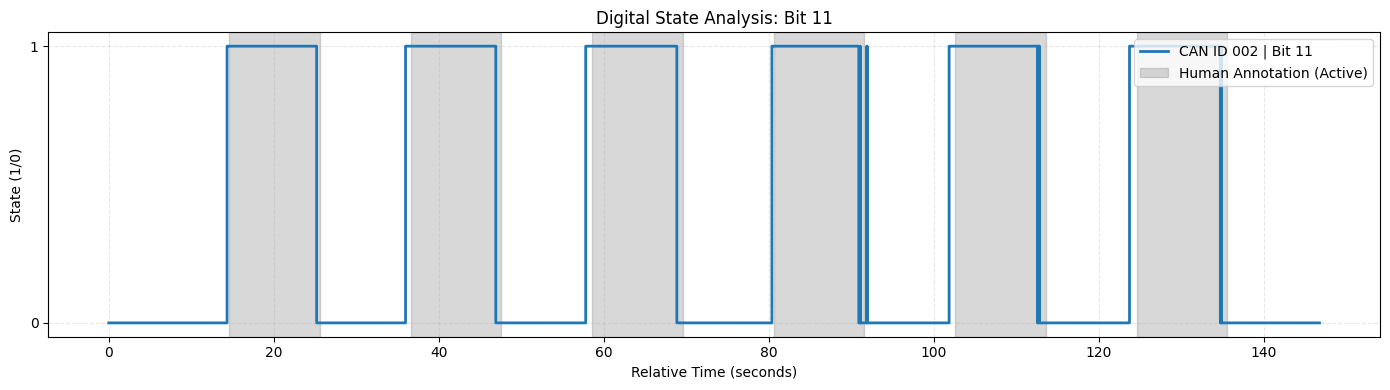

In [11]:
plot_can_bits(df_can, df_annot, target_id='002', bit_positions=[11])

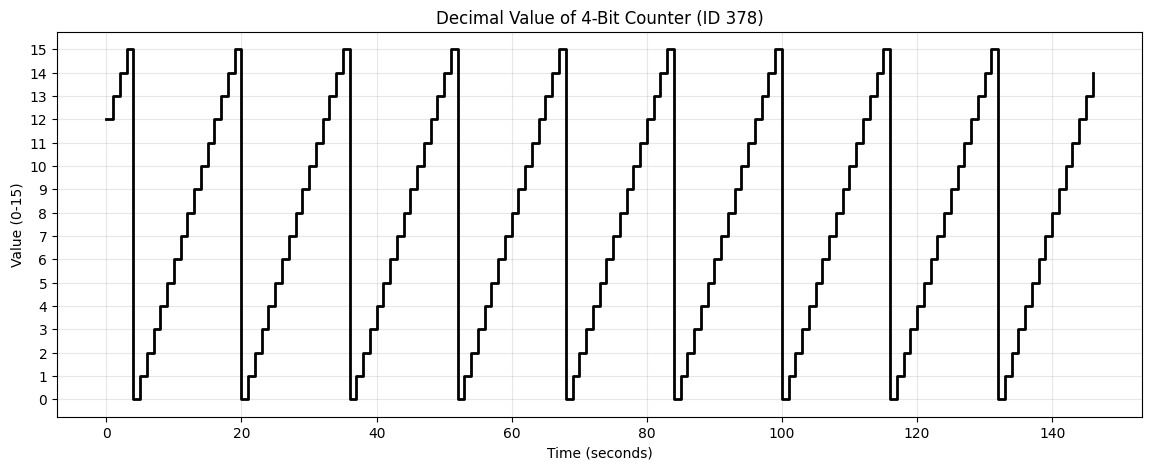

In [12]:
# 1. Filter the data
target_id = '378'
df_filtered = df_can[df_can['id'] == target_id].copy()

# 2. Define the extraction helper (Universal for hex payloads)
def get_bit_state(payload, bit_idx):
    if pd.isna(payload) or not payload: return 0
    try:
        # Padded binary string (each hex char is 4 bits)
        bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
        return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
    except: return 0

# 3. Create the bit columns FIRST (This fixes the KeyError)
for b in range(4):
    df_filtered[f'bit_{b}'] = df_filtered['payload'].apply(lambda x: get_bit_state(x, b))

# 4. Now calculate the 4-bit integer value
df_filtered['counter_value'] = (
    df_filtered['bit_0'] * 8 + 
    df_filtered['bit_1'] * 4 + 
    df_filtered['bit_2'] * 2 + 
    df_filtered['bit_3'] * 1
)

# 5. Plot the result
plt.figure(figsize=(14, 5))
plt.step(df_filtered['timestamp'] - df_filtered['timestamp'].min(), 
         df_filtered['counter_value'], where='post', color='black', lw=2)

plt.title(f"Decimal Value of 4-Bit Counter (ID {target_id})")
plt.ylabel("Value (0-15)")
plt.xlabel("Time (seconds)")
plt.yticks(range(16))
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
def plot_can_counter(df_can, target_id, start_bit=0, num_bits=4):
    """
    Extracts a range of bits from a CAN ID, converts them to a decimal 
    integer (MSB first), and plots the resulting counter.
    """
    # 1. Filter and prepare data
    df_f = df_can[df_can['id'] == target_id].copy()
    if df_f.empty:
        print(f"No data found for ID {target_id}")
        return

    # 2. Define the extraction helper
    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or not payload: return 0
        try:
            # Padded binary string (4 bits per hex char)
            bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
            return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
        except: return 0

    # 3. Extract bits and calculate decimal value
    # We use a running sum to calculate the decimal value: Σ (bit * 2^exponent)
    df_f['counter_value'] = 0
    for i in range(num_bits):
        global_bit_idx = start_bit + i
        bit_series = df_f['payload'].apply(lambda x: get_bit_state(x, global_bit_idx))
        
        # Power calculation assumes MSB is the first bit in the range (Big Endian)
        power = num_bits - 1 - i
        df_f['counter_value'] += bit_series * (2 ** power)

    # 4. Plotting
    plt.figure(figsize=(14, 5))
    rel_time = df_f['timestamp'] - df_f['timestamp'].min()
    
    plt.step(rel_time, df_f['counter_value'], where='post', color='black', lw=2)

    plt.title(f"Decimal Value of {num_bits}-Bit Counter (ID {target_id}, Bits {start_bit}-{start_bit+num_bits-1})")
    plt.ylabel(f"Value (0-{2**num_bits - 1})")
    plt.xlabel("Time (seconds)")
    plt.yticks(range(2**num_bits))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


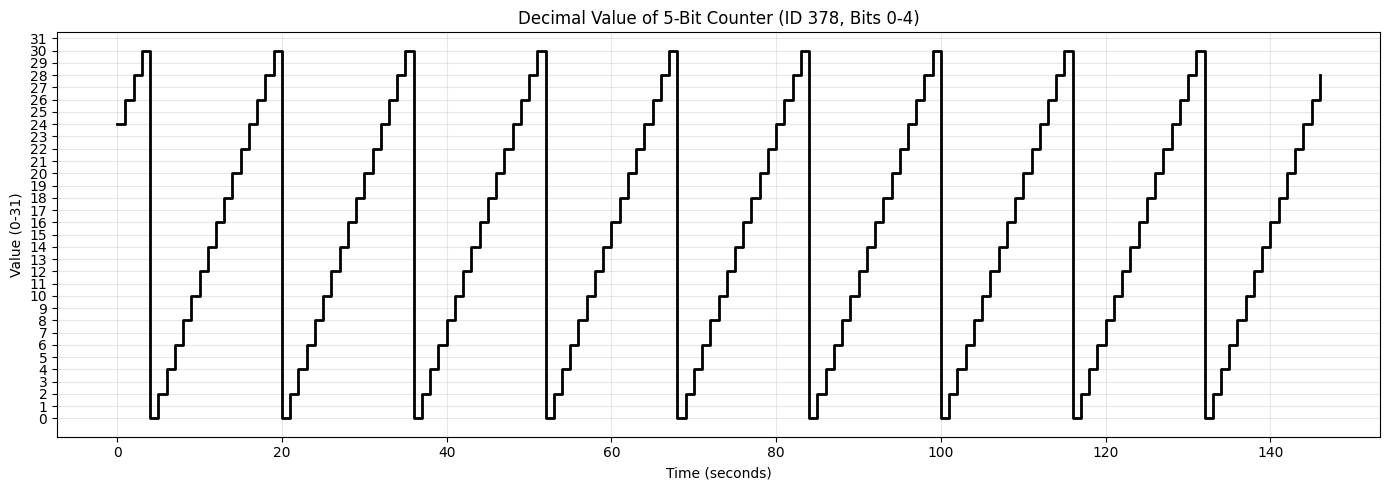

In [15]:
plot_can_counter(df_can, '378', start_bit=0, num_bits=5)

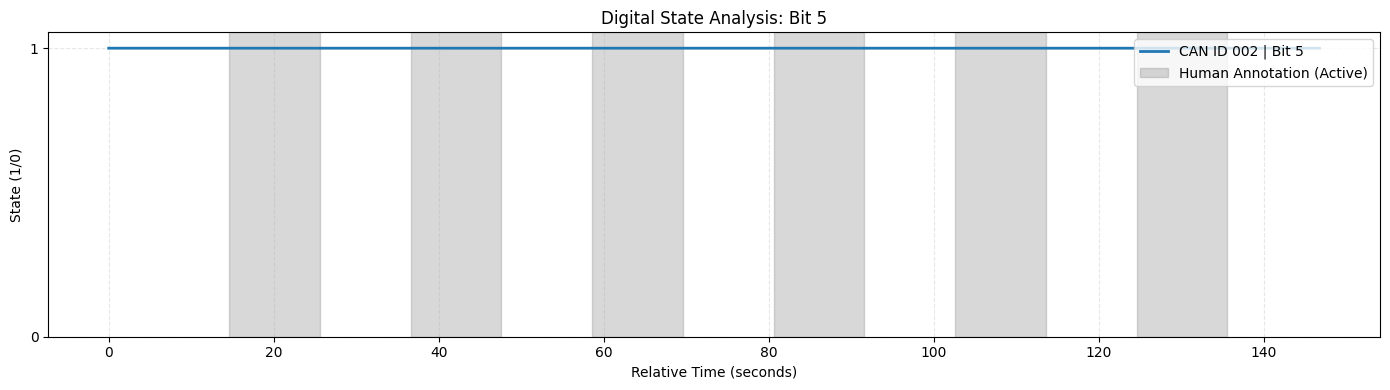

In [16]:
plot_can_bits(df_can, df_annot, target_id='002', bit_positions=[5])

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_can_counter(df_can, target_id, start_bit=0, num_bits=4, endian='big'):
    """
    Extracts a range of bits and plots them as a decimal counter.
    
    Parameters:
    - endian='big': The first bit (start_bit) is the Most Significant Bit (MSB).
    - endian='little': The first bit (start_bit) is the Least Significant Bit (LSB).
    """
    df_f = df_can[df_can['id'] == target_id].copy().sort_values('timestamp')
    if df_f.empty:
        return print(f"No data found for ID {target_id}")

    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or not payload: return 0
        try:
            # Padded binary string (4 bits per hex char)
            bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
            return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
        except: return 0

    # Calculate decimal value based on endianness
    df_f['counter_value'] = 0
    for i in range(num_bits):
        current_bit_idx = start_bit + i
        bit_series = df_f['payload'].apply(lambda x: get_bit_state(x, current_bit_idx))
        
        if endian.lower() == 'big':
            # First bit has the highest weight (e.g., 2^3, 2^2, 2^1, 2^0)
            power = num_bits - 1 - i
        else:
            # First bit has the lowest weight (e.g., 2^0, 2^1, 2^2, 2^3)
            power = i
            
        df_f['counter_value'] += bit_series * (2 ** power)

    # Plotting
    plt.figure(figsize=(14, 5))
    rel_time = df_f['timestamp'] - df_f['timestamp'].min()
    plt.step(rel_time, df_f['counter_value'], where='post', color='black', lw=2)

    plt.title(f"ID {target_id} | {num_bits}-Bit Counter ({endian.capitalize()} Endian)")
    plt.ylabel(f"Decimal Value (0-{2**num_bits - 1})")
    plt.xlabel("Time (seconds)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

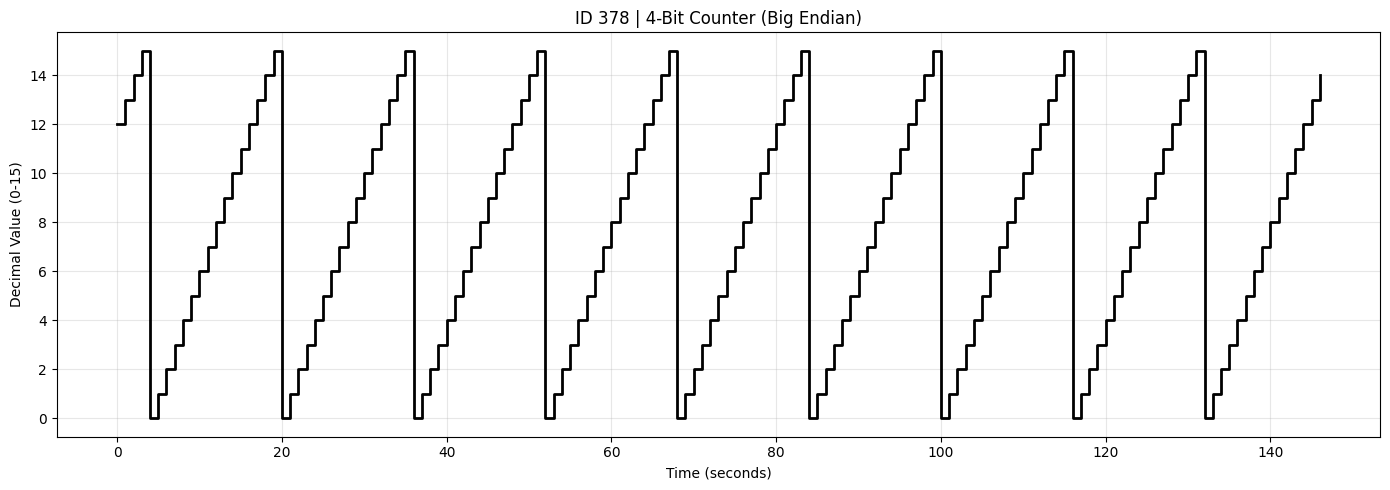

In [19]:
plot_can_counter(df_can, target_id, start_bit=0, num_bits=4, endian='big')

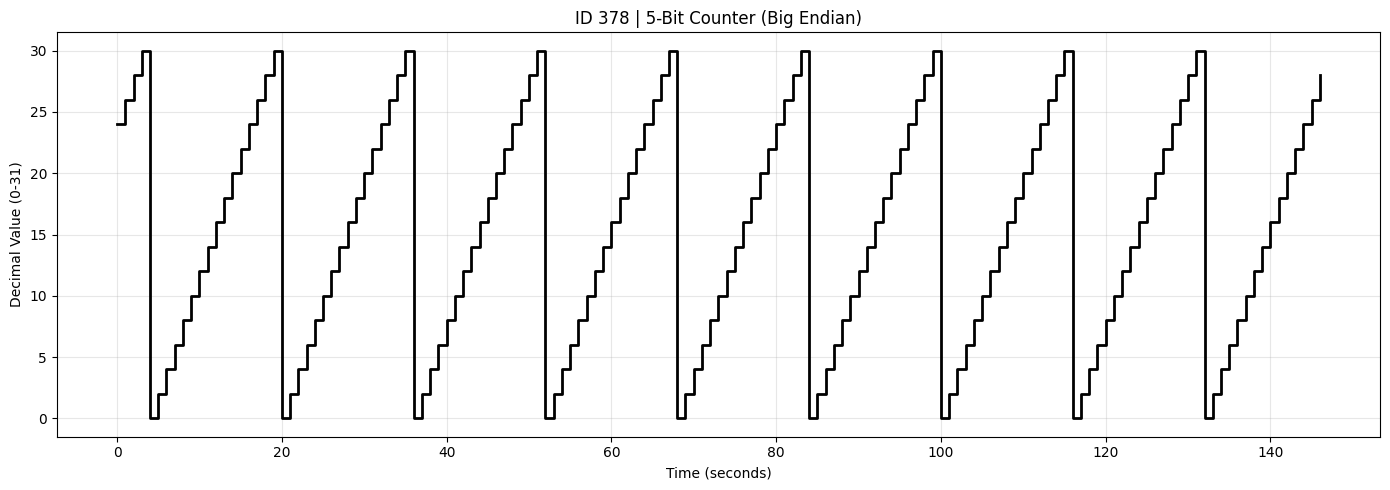

In [21]:
plot_can_counter(df_can, target_id, start_bit=0, num_bits=5, endian='big')